In [1]:
import sys
sys.path.insert(0, "..")

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.nn import functional as F

from app.vjepa_droid.transforms import make_transforms
from utils.mpc_utils import (
    compute_new_pose,
    poses_to_diff
)

In [ ]:
# Initialize VJEPA 2-AC model
encoder, predictor = torch.hub.load("facebookresearch/vjepa2", "vjepa2_ac_vit_giant", pretrained=False)
ckpt= torch.load("/mnt/4T/ADT3DCV2026/model/vjepa2/checkpoints/vjepa2-ac-vitg.pt", map_location="cpu")
def strip_module_prefix(state_dict):
    return {k.replace("module.", "", 1): v for k, v in state_dict.items()}

encoder.load_state_dict(strip_module_prefix(ckpt["encoder"]))
predictor.load_state_dict(strip_module_prefix(ckpt["predictor"]))
# Initialize transform
crop_size = 256
tokens_per_frame = int((crop_size // encoder.patch_size) ** 2)
transform = make_transforms(
    random_horizontal_flip=False,
    random_resize_aspect_ratio=(1., 1.),
    random_resize_scale=(1., 1.),
    reprob=0.,
    auto_augment=False,
    motion_shift=False,
    crop_size=crop_size,
)

Using cache found in /home/camp/.cache/torch/hub/facebookresearch_vjepa2_main
/mnt/4T/miniconda3/envs/vjepa2/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [7]:
# Load robot trajectory

play_in_reverse = False  # Use this FLAG to try loading the trajectory backwards, and see how the energy landscape changes

trajectory = np.load("franka_example_traj.npz")
np_clips = trajectory["observations"]
np_states = trajectory["states"]
if play_in_reverse:
    np_clips = trajectory["observations"][:, ::-1].copy()
    np_states = trajectory["states"][:, ::-1].copy()
np_actions = np.expand_dims(poses_to_diff(np_states[0, 0], np_states[0, 1]), axis=(0, 1))

# Convert trajectory to torch tensorst
clips = transform(np_clips[0]).unsqueeze(0)
states = torch.tensor(np_states)
actions = torch.tensor(np_actions)
print(f"clips: {clips.shape}; states: {states.shape}; actions: {actions.shape}")
print(np_clips.shape)

clips: torch.Size([1, 3, 2, 256, 256]); states: torch.Size([1, 2, 7]); actions: torch.Size([1, 1, 7])
(1, 2, 256, 256, 3)


In [ ]:
z_hat = predictor()

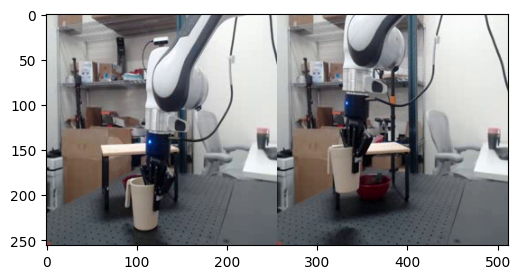

In [8]:
# Visualize loaded video frames from traj

T = len(np_clips[0])
plt.figure(figsize=(20, 3))
_ = plt.imshow(np.transpose(np_clips[0], (1, 0, 2, 3)).reshape(256, 256 * T, 3))

In [9]:
def forward_target(c, normalize_reps=True):
    B, C, T, H, W = c.size()
    c = c.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
    h = encoder(c)
    h = h.view(B, T, -1, h.size(-1)).flatten(1, 2)
    if normalize_reps:
        h = F.layer_norm(h, (h.size(-1),))
    return h


def forward_actions(z, nsamples, grid_size=0.075, normalize_reps=True, action_repeat=1):

    def make_action_grid(grid_size=grid_size):
        action_samples = []
        for da in np.linspace(-grid_size, grid_size, nsamples):
            for db in np.linspace(-grid_size, grid_size, nsamples):
                for dc in np.linspace(-grid_size, grid_size, nsamples):
                    action_samples += [torch.tensor([da, db, dc, 0, 0, 0, 0], device=z.device, dtype=z.dtype)]
        return torch.stack(action_samples, dim=0).unsqueeze(1)

    # Sample grid of actions
    action_samples = make_action_grid()
    print(f"Sampled grid of actions; num actions = {len(action_samples)}")

    def step_predictor(_z, _a, _s):
        _z = predictor(_z, _a, _s)[:, -tokens_per_frame:]
        if normalize_reps:
            _z = F.layer_norm(_z, (_z.size(-1),))
        _s = compute_new_pose(_s[:, -1:], _a[:, -1:])
        return _z, _s

    # Context frame rep and context pose
    z_hat = z[:, :tokens_per_frame].repeat(int(nsamples**3), 1, 1)  # [S, N, D]
    s_hat = states[:, :1].repeat((int(nsamples**3), 1, 1))  # [S, 1, 7]
    a_hat = action_samples  # [S, 1, 7]

    for _ in range(action_repeat):
        _z, _s = step_predictor(z_hat, a_hat, s_hat)
        z_hat = torch.cat([z_hat, _z], dim=1)
        s_hat = torch.cat([s_hat, _s], dim=1)
        a_hat = torch.cat([a_hat, action_samples], dim=1)

    return z_hat, s_hat, a_hat

def loss_fn(z, h):
    z, h = z[:, -tokens_per_frame:], h[:, -tokens_per_frame:]
    loss = torch.abs(z - h)  # [B, N, D]
    loss = torch.mean(loss, dim=[1, 2])
    return loss.tolist()

torch.Size([1, 3, 2, 256, 256])
torch.Size([1, 512, 1408])


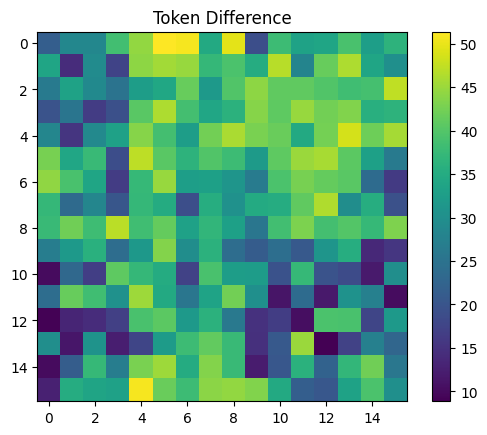

In [14]:
# Compute energy for cartesian action grid of size (nsample x nsamples x nsamples)
nsamples = 5
grid_size = 0.075
with torch.no_grad():
    h = forward_target(clips)
    print(clips.shape)
    print(h.shape)
    # z_hat, s_hat, a_hat = forward_actions(h, nsamples=nsamples, grid_size=grid_size)
    # loss = loss_fn(z_hat, h)  # jepa prediction loss
z0 = h[0, :256]
z1 = h[0, 256:]

sim = torch.nn.functional.cosine_similarity(
    z0,
    z1,
    dim=-1
)

diff = torch.norm(z0 - z1, dim=-1)

diff_map = diff.reshape(16,16)

plt.imshow(diff_map.cpu())
plt.colorbar()
plt.title("Token Difference")
plt.show()

/mnt/4T/miniconda3/envs/vjepa2/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


torch.Size([1, 256, 1408])


/mnt/4T/ADT3DCV2026/model/tmp/ipykernel_2029538/2151781285.py:85: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/4T/ADT3DCV2026/model/tmp/ipykernel_2029538/2151781285.py:85: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/4T/ADT3DCV2026/model/tmp/ipykernel_2029538/2151781285.py:85: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/4T/ADT3DCV2026/model/tmp/ipykernel_2029538/2151781285.py:85: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/4T/ADT3DCV2026/model/tmp/ipykernel_2029538/2151781285.py:85: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/4T/ADT3DCV2026/model/tmp/ipykernel_2029538/2151781285.py:85: UserWarning: Glyph 19979 (\N{CJK UNIFIE

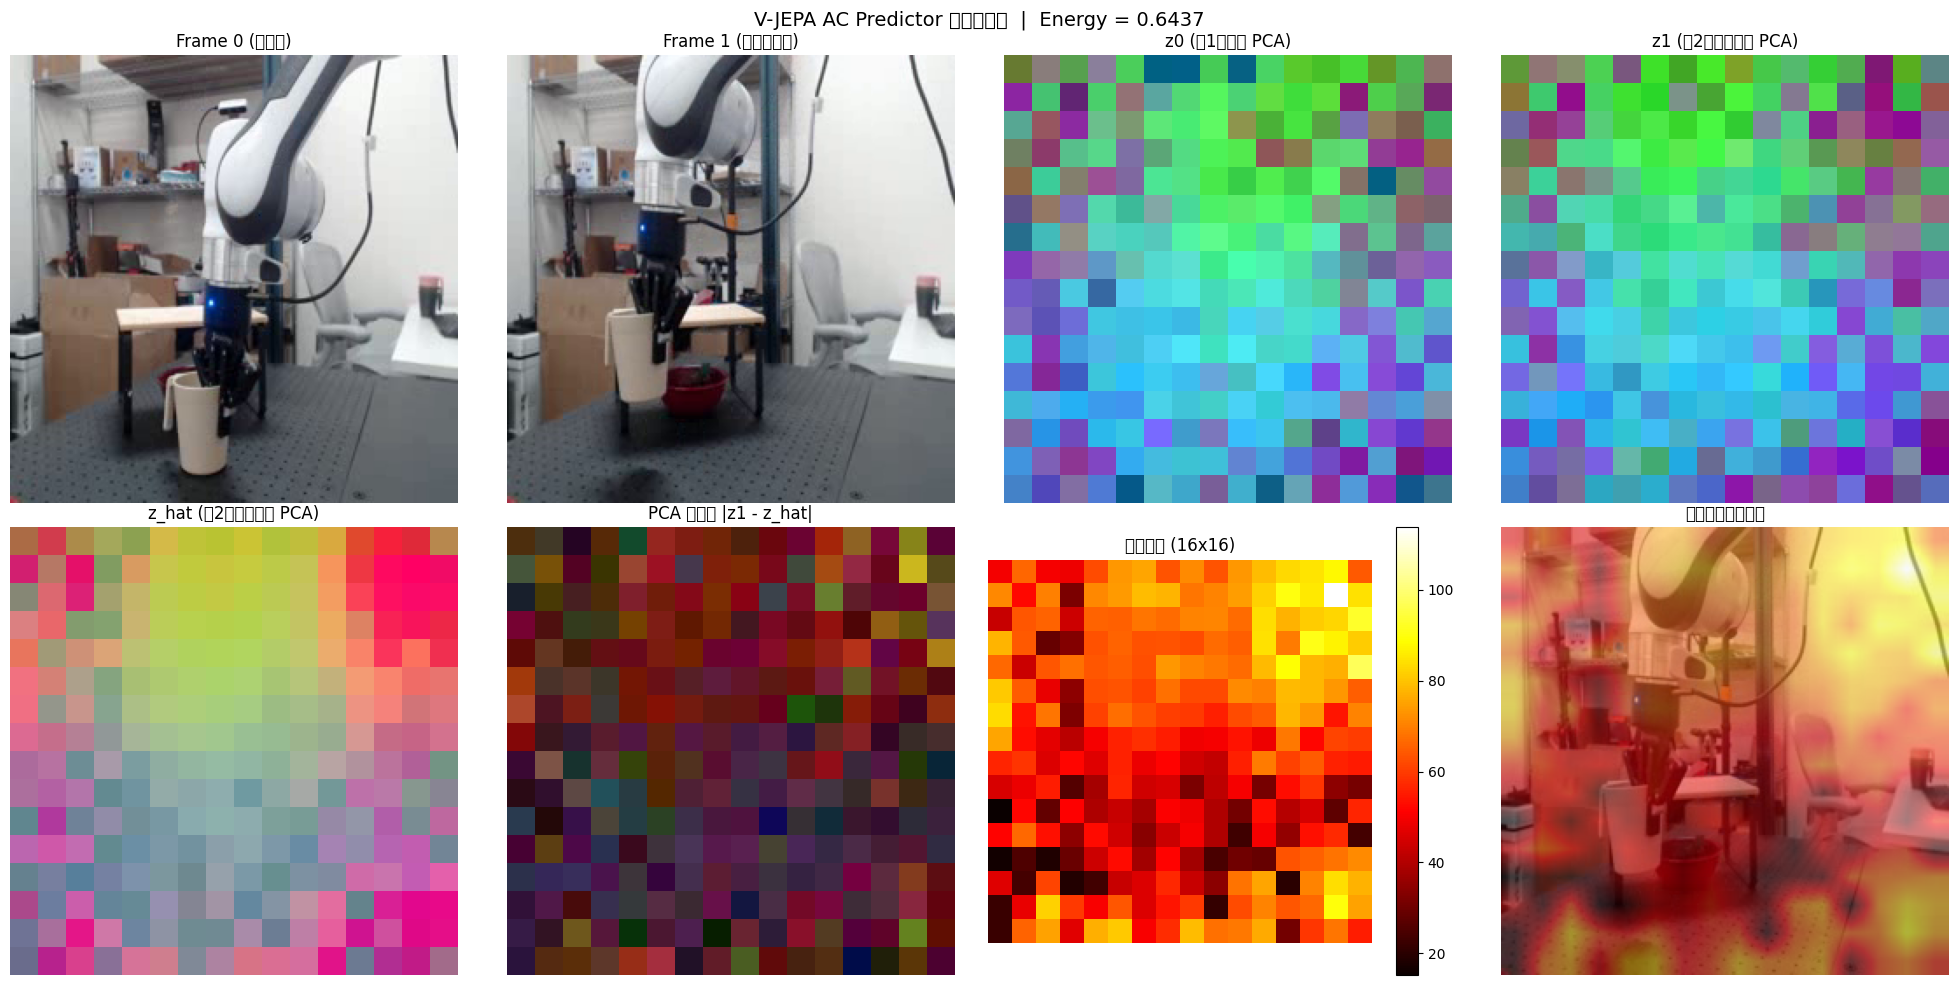

Energy (L1): 0.6437


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.decomposition import PCA


def visualize_frame_features(
    h,
    images,
    tokens_per_frame=256,
    method="norm",   # "norm" or "pca"
    alpha=0.5
):
    """
    h: [1, 2*tokens_per_frame, D]
    images: np_clips[0] -> [T, H, W, 3]
    """

    assert h.dim() == 3
    B, N, D = h.shape
    assert B == 1

    z0 = h[0, :tokens_per_frame]
    z1 = h[0, tokens_per_frame:]

    # -----------------------------
    # 1. feature reduction
    # -----------------------------
    if method == "norm":
        feat0 = torch.norm(z0, dim=-1).detach().numpy()
        feat1 = torch.norm(z1, dim=-1).detach().numpy()
    elif method == "pca":
        z = torch.cat([z0, z1], dim=0).detach().numpy()
        pca = PCA(n_components=1)
        feat = pca.fit_transform(z).squeeze()
        feat0 = feat[:tokens_per_frame]
        feat1 = feat[tokens_per_frame:]

    else:
        raise ValueError("method must be 'norm' or 'pca'")

    # -----------------------------
    # 2. reshape to token grid
    # -----------------------------
    grid_size = int(np.sqrt(tokens_per_frame))
    assert grid_size * grid_size == tokens_per_frame, "tokens_per_frame must be square"

    feat0_map = feat0.reshape(grid_size, grid_size)
    feat1_map = feat1.reshape(grid_size, grid_size)

    # -----------------------------
    # 3. upsample to image size
    # -----------------------------
    H, W = images.shape[1], images.shape[2]

    feat0_up = cv2.resize(feat0_map, (W, H))
    feat1_up = cv2.resize(feat1_map, (W, H))

    # normalize for visualization
    def norm(x):
        x = x - x.min()
        x = x / (x.max() + 1e-8)
        return x

    feat0_up = norm(feat0_up)
    feat1_up = norm(feat1_up)

    # -----------------------------
    # 4. plot overlay
    # -----------------------------
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(images[0])
    plt.imshow(feat0_up, cmap="jet", alpha=alpha)
    plt.title("Frame 0 feature map")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(images[1])
    plt.imshow(feat1_up, cmap="jet", alpha=alpha)
    plt.title("Frame 1 feature map")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return feat0_up, feat1_up

h = forward_target(clips)
states  = torch.tensor(np_states,  dtype=torch.float32)
actions = torch.tensor(np_actions, dtype=torch.float32)
print(h[:, :tokens_per_frame].shape)
h_hat = predictor(h[:, :tokens_per_frame], states[:,:1], actions)
feat0, feat1 = visualize_frame_features(
    h=h,
    images=np_clips[0],
    tokens_per_frame=256,
    method="pca",   # 或 "pca"
    alpha=0.5
)

Ground truth action (x,y,z) = (0.09,0.03,0.08)


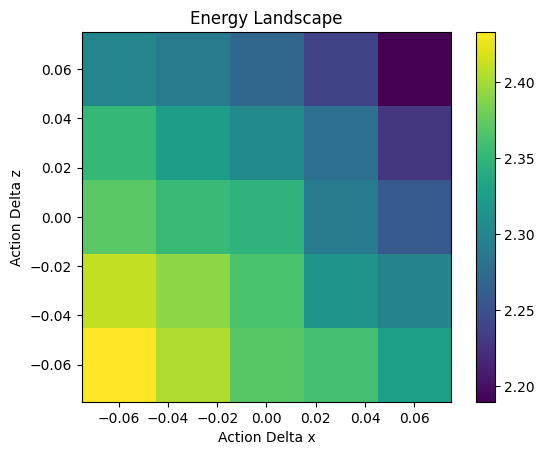

In [22]:
# Plot the energy

plot_data = []
for b, v in enumerate(loss):
    plot_data.append((
        a_hat[b, :-1, 0].sum(),
        a_hat[b, :-1, 1].sum(),
        a_hat[b, :-1, 2].sum(),
        v,
    ))

delta_x = [d[0] for d in plot_data]
delta_y = [d[1] for d in plot_data]
delta_z = [d[2] for d in plot_data]
energy = [d[3] for d in plot_data]

gt_x = actions[0, 0, 0]
gt_y = actions[0, 0, 1]
gt_z = actions[0, 0, 2]

# Create the 2D histogram
heatmap, xedges, yedges = np.histogram2d(delta_x, delta_z, weights=energy, bins=nsamples)

# Set axis labels
plt.xlabel("Action Delta x")
plt.ylabel("Action Delta z")
plt.title(f"Energy Landscape")

# Display the heatmap
print(f"Ground truth action (x,y,z) = ({gt_x:.2f},{gt_y:.2f},{gt_z:.2f})")
_ = plt.imshow(heatmap.T, origin="lower", extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis")
_ = plt.colorbar()

In [23]:
# Compute the optimal action using MPC
from utils.world_model_wrapper import WorldModel

world_model = WorldModel(
    encoder=encoder,
    predictor=predictor,
    tokens_per_frame=tokens_per_frame,
    transform=transform,
    # Doing very few CEM iterations with very few samples just to run efficiently on CPU...
    # ... increase cem_steps and samples for more accurate optimization of energy landscape
    mpc_args={
        "rollout": 2,
        "samples": 25,
        "topk": 10,
        "cem_steps": 2,
        "momentum_mean": 0.15,
        "momentum_mean_gripper": 0.15,
        "momentum_std": 0.75,
        "momentum_std_gripper": 0.15,
        "maxnorm": 0.075,
        "verbose": True
    },
    normalize_reps=True,
    device="cpu"
)

with torch.no_grad():
    h = forward_target(clips)
    z_n, z_goal = h[:, :tokens_per_frame], h[:, -tokens_per_frame:]
    s_n = states[:, :1]
    print(f"Starting planning using Cross-Entropy Method...")
    actions = world_model.infer_next_action(z_n, s_n, z_goal).cpu().numpy()

print(f"Actions returned by planning with CEM (x,y,z) = ({actions[0, 0]:.2f},{actions[0, 1]:.2f} {actions[0, 2]:.2f})")

Starting planning using Cross-Entropy Method...
[INFO    ][2026-05-25 21:53:19][utils.mpc_utils     ][cem                      ] new mean: tensor([ 0.0178,  0.0061,  0.0527, -0.1936]) tensor([0.1369, 0.1388, 0.1335, 1.2793])
[INFO    ][2026-05-25 21:53:39][utils.mpc_utils     ][cem                      ] new mean: tensor([0.0565, 0.0366, 0.0406, 0.1135]) tensor([0.1202, 0.1270, 0.1221, 0.9850])
Actions returned by planning with CEM (x,y,z) = (0.06,0.03 0.05)
